# EdgeEngine AWARE — baseline rule-based policy

**Application- and Energy-Aware Simulation Environment for Reinforcement Learning in Energy-Harvesting Edge IoT Systems**

This notebook demonstrates the simulator *without any RL training*. We drive an
energy-harvesting soil-moisture node in a field with a simple, interpretable
rule-based controller and look at what happens to the battery, to the
information the remote application receives, and to the reward an RL agent
would be optimising.

What you will see:

1. how to instantiate the environment and read its observation / action spaces;
2. what every component of the observation vector means — and why only
   *hardware-measurable* quantities are in it;
3. a full 7-day episode with the rule-based policy, rendered live;
4. episode metrics (energy, sensing, transmissions, Age of Information, …);
5. a comparison against naïve baselines (random, periodic, always-on);
6. how two configuration knobs (harvesting power and transmission energy) change the behaviour.

## 1. Setup

The package is a plain Python package: `pip install -e .` from the repository
root, or make sure the repository root is on `sys.path` as done below.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().resolve()
if not (ROOT / "edgeengine_aware").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

import edgeengine_aware as ea
from edgeengine_aware.policies import RuleBasedPolicy, RuleBasedParams, RandomPolicy, PeriodicPolicy, AlwaysOnPolicy, run_episode

print("EdgeEngine AWARE", ea.__version__, "| Gymnasium", gym.__version__)

EdgeEngine AWARE 0.1.0 | Gymnasium 1.3.0


## 2. Instantiate the environment

`EdgeEngineAwareEnv` is a standard `gymnasium.Env`. All physical and reward
parameters live in an `EdgeEngineAwareConfig` dataclass tree; here we use the
defaults (15-minute steps, 7-day episodes, a ~300 J storage element, a
few-milliwatt solar cell, a LoRa-class radio with three selectable modes).

In [2]:
config = ea.default_config()
env = ea.EdgeEngineAwareEnv(config, render_mode="rgb_array")

print("Observation space:", env.observation_space)
print("Action space     :", env.action_space)
print("Steps / episode  :", env.max_steps, f"({config.time.episode_days:g} days at {config.time.timestep_s/60:g}-minute steps)")

Observation space: Box(0.0, 1.0, (18,), float32)
Action space     : MultiDiscrete([3 4])
Steps / episode  : 672 (7 days at 15-minute steps)


## 3. The observation vector

The policy sees an 18-dimensional float32 vector in $[0,1]^{18}$. Every entry
is something a microcontroller can compute from its fuel gauge, harvester
monitor, RTC, sensor driver, radio ACKs and the last downlink message.
**No ground truth** (true soil moisture, future irradiance, channel state) is
in it — the simulator uses those only for the reward and for the plots.

In [3]:
print(env.obs_builder.describe())

idx  name                   normalisation                                 source
----------------------------------------------------------------------------------------------------
  0  battery_soc            E / E_max                                     fuel gauge / ADC
  1  harvest_power          P / harvest_ref_power_w, clipped to 1         harvester current monitor
  2  harvest_recent         P_ewma / harvest_ref_power_w, clipped to 1    computed in firmware
  3  time_of_day_sin        (sin(2*pi*t/86400) + 1) / 2                   RTC
  4  time_of_day_cos        (cos(2*pi*t/86400) + 1) / 2                   RTC
  5  measurement            moisture units (already in [0, 1])            sensor driver + RAM
  6  measurement_quality    1 - 0.8*noise/noise_low (0 none, 0.2 low, 0.8 high) hardware profile
  7  measurement_age        age / age_scale_s, clipped to 1 (1 if none)   timer
  8  time_since_tx_success  t / age_scale_s, clipped to 1 (1 if none)     timer + radio ACK
  9  app_info

The **action** is a `MultiDiscrete([3, 4])` pair *(sensing level, transmit)*:

| sensing level | meaning | transmit | meaning |
|---|---|---|---|
| 0 | keep the stored measurement | 0 | radio off |
| 1 | low-cost sample (cheap, noisy) | 1 | send the stored sample in the **fast** mode (SF7-like, 0.3 J, short range) |
| 2 | high-quality sample (expensive, accurate) | 2 | … in the **standard** mode (SF9-like, 0.6 J) |
| | | 3 | … in the **robust** mode (SF12-like, 1.2 J, long range) |

Sensing happens *before* transmission inside a step, so `(2, 2)` means "take a good sample
and send it right away in the standard mode". Whether an uplink gets through depends on the
link margin of the chosen mode against a slowly fading path loss; the node learns the path loss
from the acknowledgements (observation `path_loss_est`).

In [4]:
obs, info = env.reset(seed=0)
for name, value in env.obs_builder.to_dict(obs).items():
    print(f"{name:22s} {value:6.3f}")
a = env.action_space.sample()
print("\nrandom action:", a, "->", ea.describe_action(a, tuple(m.name for m in config.communication.modes)))

battery_soc             0.500
harvest_power           0.000
harvest_recent          0.000
time_of_day_sin         0.500
time_of_day_cos         1.000
measurement             0.000
measurement_quality     0.000
measurement_age         1.000
time_since_tx_success   1.000
app_info_age            1.000
reported_value          0.000
app_priority            0.000
importance              0.000
link_quality            1.000
path_loss_est           1.000
sense_low_cost          0.000
sense_high_cost         0.002
tx_cost                 0.002

random action: [2 3] -> high-quality sensing / transmit (robust)


## 4. The rule-based baseline

`RuleBasedPolicy` implements the Gymnasium-independent `Policy` protocol
(`act(observation) -> action`). It only reads the observation vector (plus the flash constants
of the `NodeProfile`, for the radio link-budget table), so the same object can run inside the
simulator or inside the firmware loop of `edgeengine_aware.deployment.NodeController`. Its
rules (see the docstring):

1. **Deep economy** — SoC below 20 %: one high-quality report every 8 h, nothing else.
2. **Retry** — a fresh high-quality sample that was not acknowledged is retransmitted.
3. **Scheduled report** — when the information at the application is older than the
   report interval (2 h routine / 1 h elevated / 30 min urgent; doubled below 50 % SoC,
   shortened when the battery is full or the sun is strong): high-quality sample + transmit.
   Economy mode keeps the sample quality and saves energy by reporting less often — a cheap
   noisy sample is worth little to the application, a missed hour is cheap.
4. **Event report** — a cheap check that differs a lot from the reported value, or an
   important value near a stress threshold: high-quality sample + transmit now.
5. **Check** — otherwise, a low-cost sample every hour (never in economy mode).

**Radio mode:** the cheapest mode whose expected margin — from the node's path-loss estimate
and the link-budget table — is at least 4 dB; one mode up after recent failures; the standard
mode before the first acknowledgement.

It is deliberately simple and interpretable, not optimal.

In [5]:
import inspect
print(inspect.getsource(RuleBasedParams))

@dataclass
class RuleBasedParams:
    """Thresholds of the interpretable baseline (observation units unless noted)."""

    soc_critical: float = 0.20
    """Below this SoC: deep economy - one report every ``deep_eco_interval_h``,
    nothing else, unless the application is urgent and starving."""

    soc_low: float = 0.50
    """Below this SoC: economy mode (report interval stretched, no checks).
    Half of the storage is the trigger because a 300 J buffer covers only a
    few cloudy days: waiting for the battery to be nearly empty is too late."""

    deep_eco_interval_h: float = 8.0
    """Report interval below ``soc_critical`` (still high-quality samples: a
    cheap noisy sample is worth little to the application)."""

    soc_high: float = 0.70
    """Above this SoC (or under strong harvesting): generous mode."""

    harvest_strong: float = 0.5
    """Normalised recent-harvest level considered 'strong sun'."""

    report_interval_h: tuple[float, float, float] = (2.0, 1.0, 0.

## 5. One complete episode, rendered

We run 7 simulated days and call `render()` a few times. `render_mode="rgb_array"`
returns an image (works headless); `render_mode="human"` would update a live
Matplotlib window and `render_mode="ansi"` prints a compact text dashboard.

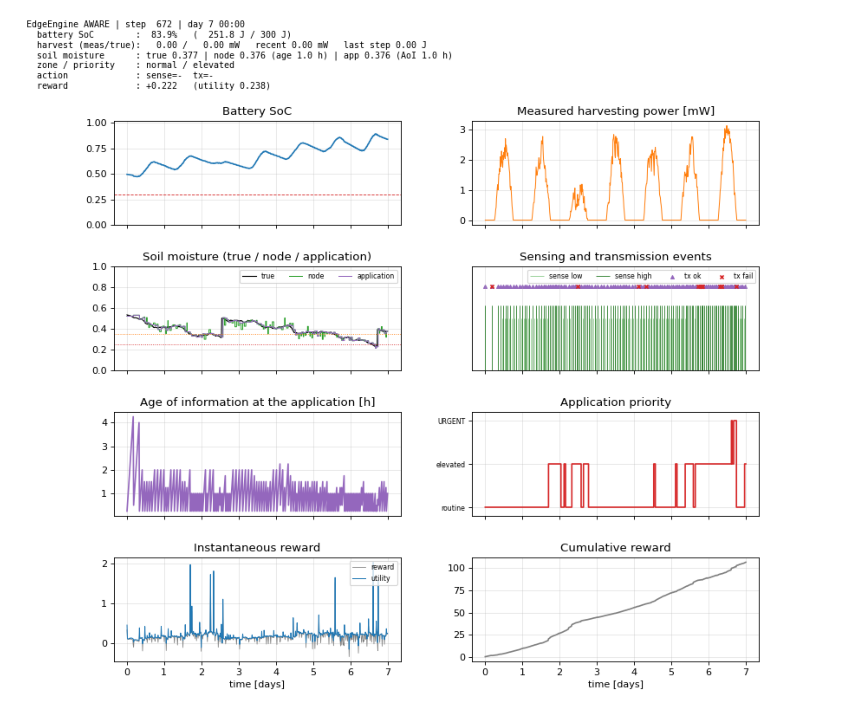

Episode finished after 672 steps, total reward = 106.65


In [6]:
from edgeengine_aware.observation import NodeProfile
profile = NodeProfile.from_config(config)
policy = RuleBasedPolicy(profile=profile)
obs, info = env.reset(seed=42)
policy.reset()

total_reward = 0.0
rewards, socs = [], []
frames = []
done = False
step = 0
while not done:
    action = policy.act(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    rewards.append(reward); socs.append(info["battery_soc"])
    done = terminated or truncated
    step += 1
    if step % 96 == 0 or done:          # once per simulated day
        frames.append(env.render())

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(frames[-1]); ax.axis("off"); plt.show()
print(f"Episode finished after {step} steps, total reward = {total_reward:.2f}")

The dashboard title is the compact per-step status (the same text that
`render_mode="ansi"` returns); the panels show battery, harvesting, the three
views of soil moisture (true / node / application), sensing and transmission
events, the Age of Information at the application, the application priority
and the reward.

In [7]:
env_txt = ea.EdgeEngineAwareEnv(config, render_mode="ansi")
o, _ = env_txt.reset(seed=42)
p = RuleBasedPolicy(profile=profile)
for _ in range(40):
    o, *_ = env_txt.step(p.act(o))
print(env_txt.render())

EdgeEngine AWARE | step   40 | day 0 10:00
  battery SoC        :  50.3%   (  150.8 J / 300 J)
  harvest (meas/true):   2.09 /   1.88 mW   recent 1.45 mW   last step 1.64 J
  soil moisture      : true 0.491 | node 0.490 (age 2.0 h) | app 0.490 (AoI 2.0 h)
  zone / priority    : normal / routine
  action             : sense=-  tx=-
  reward             : +0.116   (utility 0.133)


## 6. Episode metrics

`env.metrics` accumulates the episode-level metrics (also available at every step
as `info["metrics"]`). Age of Information (AoI) is the age of the freshest
measurement the *application* holds: time since the last delivery plus the age the
sample already had when it was sent.

In [8]:
print(env.metrics.summary())

total_reward               : 106.65
total_application_utility  : 133.23
total_harvested_energy_j   : 423.3 J
total_consumed_energy_j    : 321.5 J
baseline_energy_j          : 121.0 J
sensing_energy_j           : 80.2 J
communication_energy_j     : 120.3 J
wasted_harvest_energy_j    : 0.0 J
n_sensing                  : 187
n_high_quality_sensing     : 123
n_transmissions            : 133
n_successful_transmissions : 120
transmissions_per_mode     : {1: 43, 2: 75, 0: 15}
delivery_ratio             : 0.90
n_rejected_actions         : 0
average_battery_soc        : 0.672
min_battery_soc            : 0.473
fraction_low_battery       : 0.000
battery_depletion_events   : 0
average_aoi_h              : 0.95 h
max_aoi_h                  : 4.25 h


### Reward decomposition

The reward is *application utility minus resource costs and penalties*. Every
component is returned in `info["reward_components"]` and accumulated in
`env.metrics.reward_components`, so one can see what the agent is actually paid for.

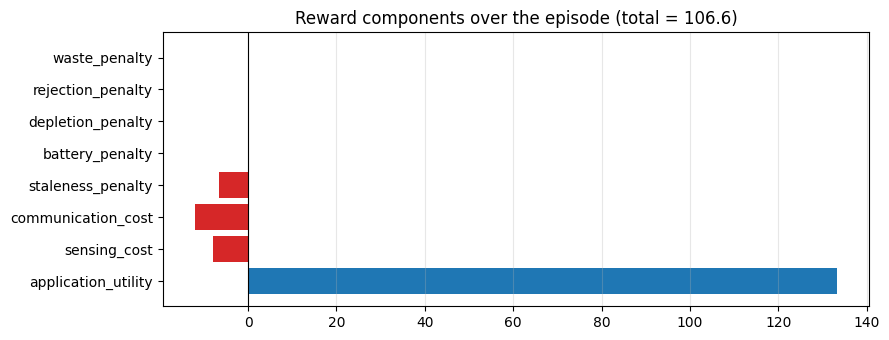

In [9]:
rc = env.metrics.reward_components
labels = [k for k in rc if k != "total"]
values = [rc[k] if k == "application_utility" else -rc[k] for k in labels]
fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ["tab:blue" if v >= 0 else "tab:red" for v in values]
ax.barh(labels, values, color=colors); ax.axvline(0, color="k", lw=0.8)
ax.set_title(f"Reward components over the episode (total = {rc['total']:.1f})"); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

### Time series

`env.log` keeps the per-step history used by the renderer; we plot the most
interesting signals side by side.

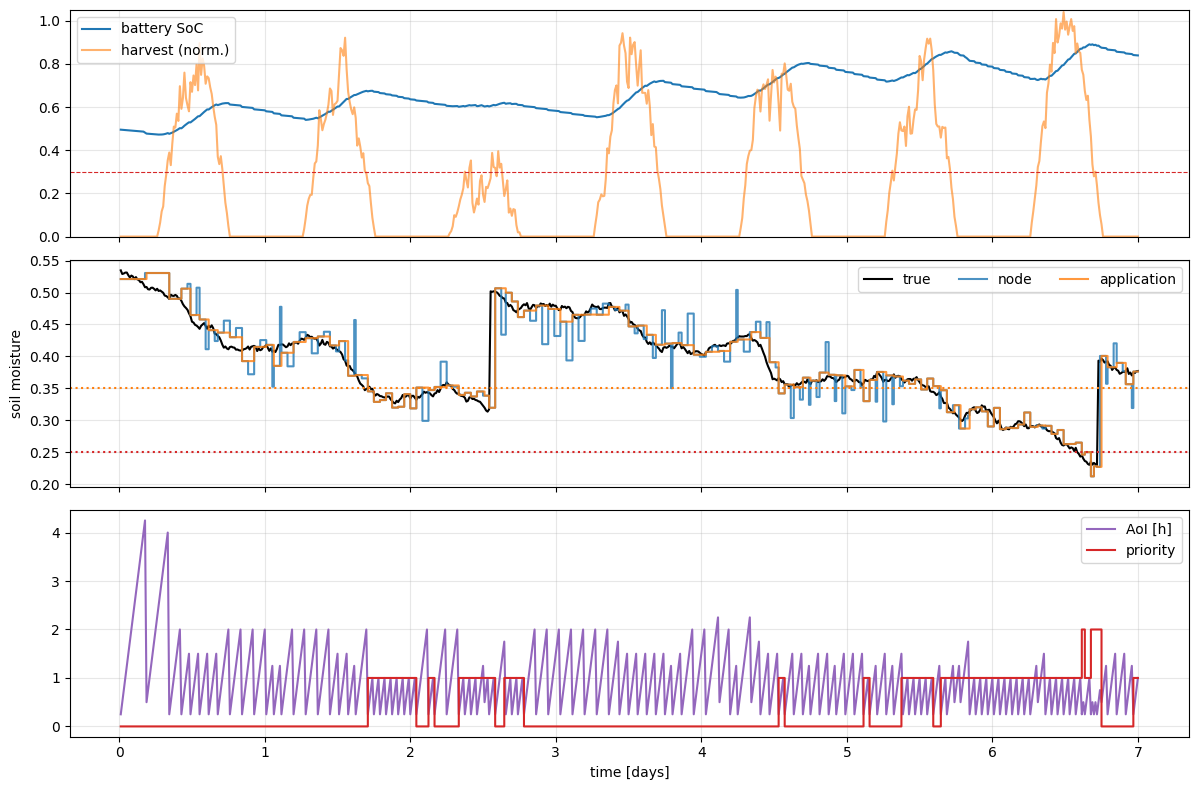

In [10]:
log = env.log
t = np.asarray(log.time_s) / 86400
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(t, log.soc, label="battery SoC"); axes[0].plot(t, np.asarray(log.harvest_power_w) / config.observation.harvest_ref_power_w, alpha=0.6, label="harvest (norm.)")
axes[0].axhline(config.reward.safe_soc, color="tab:red", ls="--", lw=0.8); axes[0].legend(); axes[0].set_ylim(0, 1.05); axes[0].grid(alpha=0.3)
axes[1].plot(t, log.true_moisture, "k", label="true"); axes[1].step(t, log.measured_moisture, where="post", label="node", alpha=0.8); axes[1].step(t, log.app_moisture, where="post", label="application", alpha=0.8)
axes[1].axhline(config.agriculture.warning_threshold, color="tab:orange", ls=":"); axes[1].axhline(config.agriculture.critical_threshold, color="tab:red", ls=":"); axes[1].legend(ncol=3); axes[1].set_ylabel("soil moisture"); axes[1].grid(alpha=0.3)
axes[2].plot(t, np.asarray(log.aoi_s) / 3600, color="tab:purple", label="AoI [h]"); axes[2].step(t, log.priority, where="post", color="tab:red", label="priority"); axes[2].legend(); axes[2].set_xlabel("time [days]"); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Comparison with naïve baselines

The same `run_episode` helper works with any object exposing `act()` /
`reset()`. We average over a few seeds (weather, rain and channel are stochastic).

In [11]:
def evaluate(policy_factory, seeds=range(5), cfg=config):
    e = ea.EdgeEngineAwareEnv(cfg)
    rows = []
    for s in seeds:
        res = run_episode(e, policy_factory(), seed=s)
        m = e.metrics
        rows.append(dict(reward=res.total_reward, utility=m.total_application_utility, harvested_J=m.total_harvested_energy_j,
                         consumed_J=m.total_consumed_energy_j, sensing=m.n_sensing, tx=m.n_transmissions, delivered=m.n_successful_transmissions,
                         min_soc=m.min_battery_soc, low_batt_frac=m.fraction_low_battery, depletions=m.battery_depletion_events, aoi_h=m.average_aoi_s / 3600))
    return {k: float(np.mean([r[k] for r in rows])) for k in rows[0]}

baselines = {
    "rule-based (adaptive radio)": lambda: RuleBasedPolicy(profile=profile),
    "rule-based (standard mode only)": RuleBasedPolicy,
    "random": lambda: RandomPolicy(seed=0),
    "periodic 1 h, HQ, standard mode": lambda: PeriodicPolicy(period_steps=4, sensing_level=2, tx=2),
    "periodic 1 h, HQ, fast mode": lambda: PeriodicPolicy(period_steps=4, sensing_level=2, tx=1),
    "periodic 3 h, HQ, standard mode": lambda: PeriodicPolicy(period_steps=12, sensing_level=2, tx=2),
    "periodic 3 h, HQ, robust mode": lambda: PeriodicPolicy(period_steps=12, sensing_level=2, tx=3),
    "always on": AlwaysOnPolicy,
}
results = {name: evaluate(f) for name, f in baselines.items()}

header = f"{'policy':34s} {'reward':>8s} {'utility':>8s} {'harv J':>7s} {'cons J':>7s} {'sens':>5s} {'tx':>5s} {'deliv':>5s} {'minSoC':>7s} {'low%':>5s} {'depl':>5s} {'AoI h':>6s}"
print(header); print("-" * len(header))
for name, r in results.items():
    print(f"{name:34s} {r['reward']:8.1f} {r['utility']:8.1f} {r['harvested_J']:7.0f} {r['consumed_J']:7.0f} {r['sensing']:5.0f} {r['tx']:5.0f} {r['delivered']:5.0f} {r['min_soc']:7.2f} {100*r['low_batt_frac']:5.0f} {r['depletions']:5.1f} {r['aoi_h']:6.2f}")

policy                               reward  utility  harv J  cons J  sens    tx deliv  minSoC  low%  depl  AoI h
-----------------------------------------------------------------------------------------------------------------
rule-based (adaptive radio)            95.1    125.7     446     359   210   164   149    0.47     0   0.0   0.87
rule-based (standard mode only)        90.2    124.0     446     375   245   217   133    0.47     0   0.0   1.12
random                                -89.5    108.7     446     590   406   441   298    0.01    70   4.8   1.27
periodic 1 h, HQ, standard mode        92.1    124.1     446     323   168   168   123    0.45     0   0.0   1.35
periodic 1 h, HQ, fast mode            55.6    106.9     446     272   168   168    57    0.46     0   0.0   5.09
periodic 3 h, HQ, standard mode        88.3    118.2     446     188    56    56    48    0.47     0   0.0   2.45
periodic 3 h, HQ, robust mode          91.9    120.5     446     222    56    56    53  

Reading the table:

* **always on** collects the most information but drains the ~300 J storage in
  a couple of days, browns out and is heavily penalised;
* **periodic** duty-cycling is a strong baseline when the period *and the radio mode* happen
  to match the energy budget and the link — but it is blind to weather, to the battery, to the
  link and to what the application actually needs (the fast mode loses most packets, the
  robust one is safe but twice as expensive);
* the **rule-based** policy stays sustainable while reacting to priority, to sudden changes and
  to the link estimate; choosing the radio mode from the path-loss estimate is worth several
  reward units over the same rules with a fixed mode.

## 8. Changing configuration parameters

Everything is a dataclass field. Below we (a) halve the solar panel and (b) triple
the transmission energy, and watch the rule-based policy adapt — or fail to.

In [12]:
def with_changes(**changes):
    cfg = ea.default_config()
    for path, value in changes.items():
        obj, *attrs, last = [cfg] + path.split(".")
        for a in attrs:
            obj = getattr(obj, a)
        setattr(obj, last, value)
    return cfg

import dataclasses
def with_radio_energy_scale(k):
    cfg = ea.default_config()
    cfg.communication.modes = tuple(dataclasses.replace(m, energy_j=m.energy_j * k) for m in cfg.communication.modes)
    return cfg

scenarios = {
    "default": ea.default_config(),
    "half solar panel": with_changes(**{"harvesting.max_power_w": 0.0025}),
    "3x transmission energy": with_radio_energy_scale(3.0),
    "cloudier climate": with_changes(**{"harvesting.clearness_mean": 0.4}),
    "far from the gateway (+6 dB)": with_changes(**{"communication.path_loss_mean_db": 145.0}),
}
for name, cfg in scenarios.items():
    r = evaluate(lambda cfg=cfg: RuleBasedPolicy(profile=NodeProfile.from_config(cfg)), cfg=cfg)
    print(f"{name:30s} reward {r['reward']:7.1f}  utility {r['utility']:6.1f}  tx {r['tx']:5.0f}  min SoC {r['min_soc']:.2f}  low-battery {100*r['low_batt_frac']:4.0f}%  AoI {r['aoi_h']:.2f} h")

default                        reward    95.1  utility  125.7  tx   164  min SoC 0.47  low-battery    0%  AoI 0.87 h


half solar panel               reward    91.4  utility  122.0  tx   113  min SoC 0.27  low-battery    8%  AoI 1.53 h


3x transmission energy         reward    65.7  utility  124.3  tx   124  min SoC 0.21  low-battery   10%  AoI 1.37 h


cloudier climate               reward    94.2  utility  124.7  tx   139  min SoC 0.36  low-battery    6%  AoI 1.23 h


far from the gateway (+6 dB)   reward    88.8  utility  125.5  tx   172  min SoC 0.44  low-battery    0%  AoI 0.98 h


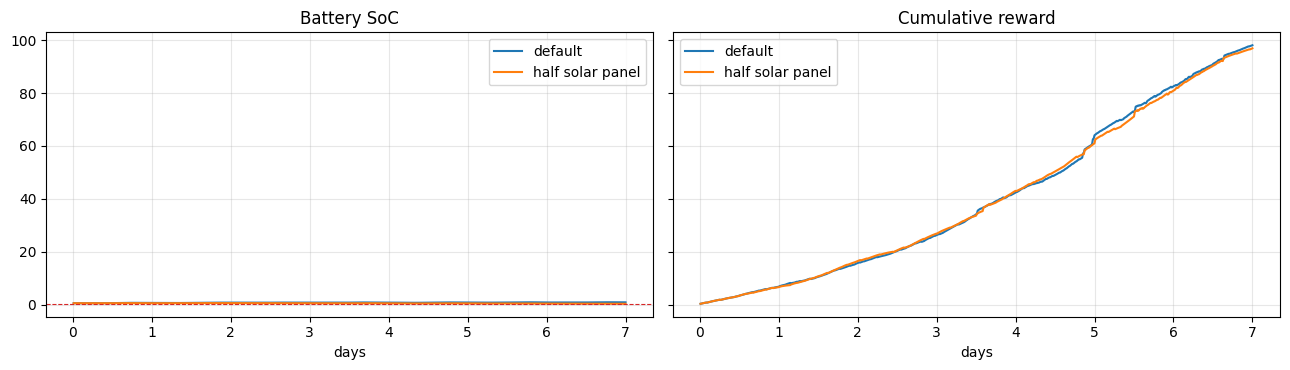

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for name, cfg in [("default", scenarios["default"]), ("half solar panel", scenarios["half solar panel"])]:
    e = ea.EdgeEngineAwareEnv(cfg)
    run_episode(e, RuleBasedPolicy(profile=NodeProfile.from_config(cfg)), seed=3)
    axes[0].plot(np.asarray(e.log.time_s) / 86400, e.log.soc, label=name)
    axes[1].plot(np.asarray(e.log.time_s) / 86400, np.cumsum(e.log.reward), label=name)
axes[0].set_title("Battery SoC"); axes[0].set_xlabel("days"); axes[0].axhline(config.reward.safe_soc, color="tab:red", ls="--", lw=0.8); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Cumulative reward"); axes[1].set_xlabel("days"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. The same policy on a (mock) hardware backend

`deployment.NodeController` is the firmware main loop written against the
hardware interfaces (`Clock`, `EnergyStorage`, `EnergySource`, `Sensor`, `Radio`,
`RemoteApplication`). Here the drivers are mocks with **no access to any ground
truth** — yet the very same `RuleBasedPolicy` object runs unchanged, fed by the
same `ObservationBuilder` and the same energy-feasibility rule. All constants the
loop needs (energy profile, timestep, baseline, reserve, normalisation) travel in
the `NodeProfile`, which is also what gets exported with the policy.

In [14]:
from edgeengine_aware.deployment import NodeController, make_mock_backend, export_policy
from edgeengine_aware.observation import NodeProfile

profile = NodeProfile.from_config(config)
hw = make_mock_backend(profile)                       # fake drivers + a minimal power-path emulation
controller = NodeController(hw, profile, RuleBasedPolicy(profile=profile), priority_update_mode=config.communication.priority_update_mode)
for cycle in range(24):
    report = controller.run_cycle()
    if report.executed_sensing_level or report.executed_transmit:
        mode = config.communication.modes[report.tx_mode].name if report.executed_transmit else "-"
        print(f"t={report.time_s/3600:5.2f} h  SoC={report.observation[0]:.3f}  requested={report.requested_action}  sensed level {report.executed_sensing_level}  tx={mode} ack={report.tx_success}")
    hw.end_of_cycle(report)                            # the board sleeps until the next wake-up

bundle = export_policy(controller.policy, profile, policy_type="rule_based", notes="baseline exported from the notebook")
print("\nPolicy bundle keys:", list(bundle.__dict__.keys()))
print("observation dim:", bundle.observation_dim, "| action encoding:", bundle.action_encoding["nvec"])

t= 0.00 h  SoC=0.500  requested=(2, 2)  sensed level 2  tx=standard ack=True
t= 4.00 h  SoC=0.486  requested=(2, 3)  sensed level 2  tx=robust ack=True

Policy bundle keys: ['policy_type', 'observation_names', 'observation_normalisation', 'profile', 'action_encoding', 'model', 'metadata']
observation dim: 18 | action encoding: [3, 4]


## 10. Where to go from here

* **Train an RL agent.** The environment is registered as `EdgeEngineAware-v0` and is
  compatible with Stable-Baselines3 (`MultiDiscrete` actions → PPO / A2C; flatten to 12
  actions for DQN with `rl.FlatActionWrapper`). `examples/train_rl.ipynb` does exactly this.
* **Domain randomisation.** Set `config.randomization.enabled = True` to perturb
  sensor noise, energy costs, packet success probability, solar intensity, cloudiness,
  battery capacity and MCU consumption at every reset.
* **Deploy.** Export the policy with `deployment.export_policy`, port the
  `ObservationBuilder` constants and the action encoding to firmware, and run the
  same decision logic on the real node — see `docs/deployment.md`.